In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../cleaned_superstore.csv")

In [4]:
X = df[["Sales", "Profit"]]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

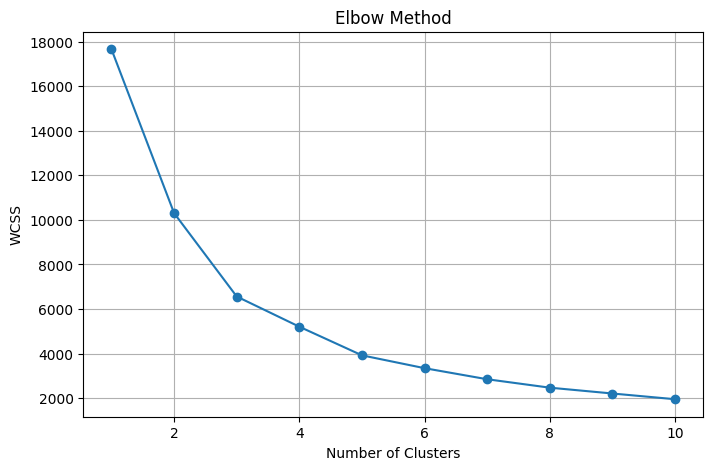

In [7]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [11]:
df[["Sales", "Profit", "Cluster"]].head()

,Sales,Profit,Cluster
0,261.960,41.9136,3
1,14.620,6.8714,0
2,22.368,2.5164,0
3,48.860,14.1694,0
4,7.280,1.9656,0


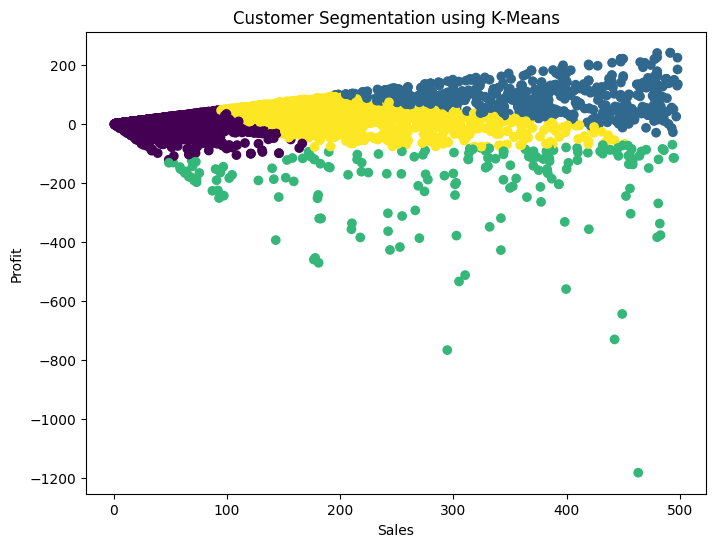

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(df["Sales"], df["Profit"], c=df["Cluster"])

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

In [14]:
df.to_csv("../data/customer_segments.csv", index=False)